In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

from sklearn.neural_network import MLPClassifier
import joblib


In [31]:
# Load the dataset
df = pd.read_csv('SaYoPillow.csv')

In [32]:
# Mapping of short column names to full names
column_mapping = {
    'sr': 'snoring_rate',
    'rr': 'respiration_rate',
    't': 'body_temperature',
    'lm': 'limb_movement',
    'bo': 'blood_oxygen',
    'rem': 'eye_movement',
    'sr.1': 'sleeping_hours',
    'hr': 'heart_rate',
    'sl': 'stress_level'
}

In [33]:
# Rename the columns
df.rename(columns=column_mapping, inplace=True)

In [34]:
df.columns

Index(['snoring_rate', 'respiration_rate', 'body_temperature', 'limb_movement',
       'blood_oxygen', 'eye_movement', 'sleeping_hours', 'heart_rate',
       'stress_level'],
      dtype='object')

In [35]:
df.head()

,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,eye_movement,sleeping_hours,heart_rate,stress_level
0,93.80,25.680,91.840,16.600,89.840,99.60,1.840,74.20,3
1,91.64,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.00,20.000,96.000,10.000,95.000,85.00,7.000,60.00,1
3,85.76,23.536,90.768,13.920,88.768,96.92,0.768,68.84,3
4,48.12,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0


In [36]:
df.tail()

,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,eye_movement,sleeping_hours,heart_rate,stress_level
625,69.600,20.960,92.960,10.960,90.960,89.80,3.440,62.40,2
626,48.440,17.376,98.064,6.752,96.376,73.76,8.376,53.44,0
627,97.504,27.504,86.880,17.752,84.256,101.88,0.000,78.76,4
628,58.640,19.728,95.728,9.728,94.592,84.32,6.728,59.32,1
629,73.920,21.392,93.392,11.392,91.392,91.96,4.088,63.48,2


In [37]:
df.describe()

,snoring_rate,respiration_rate,body_temperature,limb_movement,blood_oxygen,eye_movement,sleeping_hours,heart_rate,stress_level
count,630.000000,630.000000,630.00000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000
mean,71.600000,21.800000,92.80000,11.700000,90.900000,88.500000,3.700000,64.500000,2.000000
std,19.372833,3.966111,3.52969,4.299629,3.902483,11.893747,3.054572,9.915277,1.415337
min,45.000000,16.000000,85.00000,4.000000,82.000000,60.000000,0.000000,50.000000,0.000000
25%,52.500000,18.500000,90.50000,8.500000,88.500000,81.250000,0.500000,56.250000,1.000000
50%,70.000000,21.000000,93.00000,11.000000,91.000000,90.000000,3.500000,62.500000,2.000000
75%,91.250000,25.000000,95.50000,15.750000,94.250000,98.750000,6.500000,72.500000,3.000000
max,100.000000,30.000000,99.00000,19.000000,97.000000,105.000000,9.000000,85.000000,4.000000


In [38]:
df.dtypes

snoring_rate        float64
respiration_rate    float64
body_temperature    float64
limb_movement       float64
blood_oxygen        float64
eye_movement        float64
sleeping_hours      float64
heart_rate          float64
stress_level          int64
dtype: object

In [39]:
df.isnull().sum()

snoring_rate        0
respiration_rate    0
body_temperature    0
limb_movement       0
blood_oxygen        0
eye_movement        0
sleeping_hours      0
heart_rate          0
stress_level        0
dtype: int64

In [40]:
# Convert to Binary Stress Level
df['stress_level'] = df['stress_level'].apply(lambda x: 0 if x <= 2 else 1)
print(df['stress_level'].value_counts())


stress_level
0    378
1    252
Name: count, dtype: int64


## EDA

In [41]:
# Check unique values in target
print("\n Stress Level Distribution:")
print(df['stress_level'].value_counts())


 Stress Level Distribution:
stress_level
0    378
1    252
Name: count, dtype: int64


C:\Users\093\AppData\Local\Temp\ipykernel_10680\3792911645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stress_level', data=df, palette='viridis')


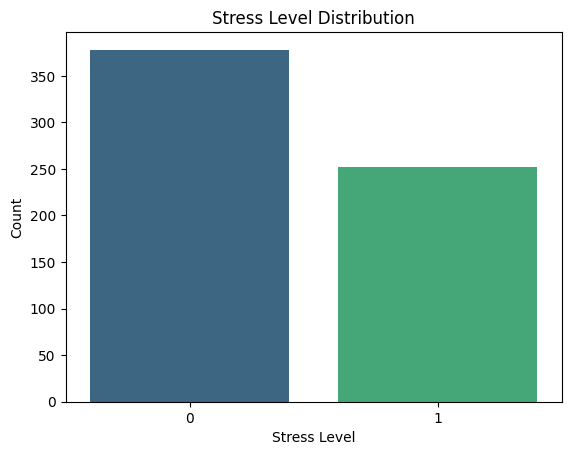

In [42]:
# Plot class distribution
sns.countplot(x='stress_level', data=df, palette='viridis')
plt.title('Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()

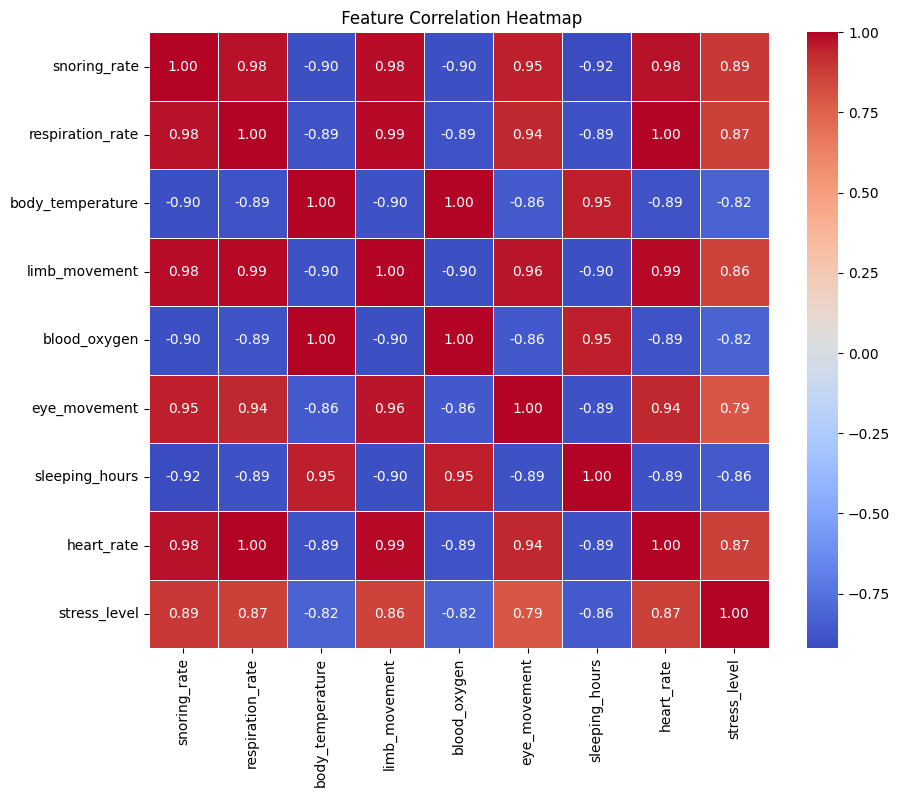

In [43]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title(" Feature Correlation Heatmap")
plt.show()

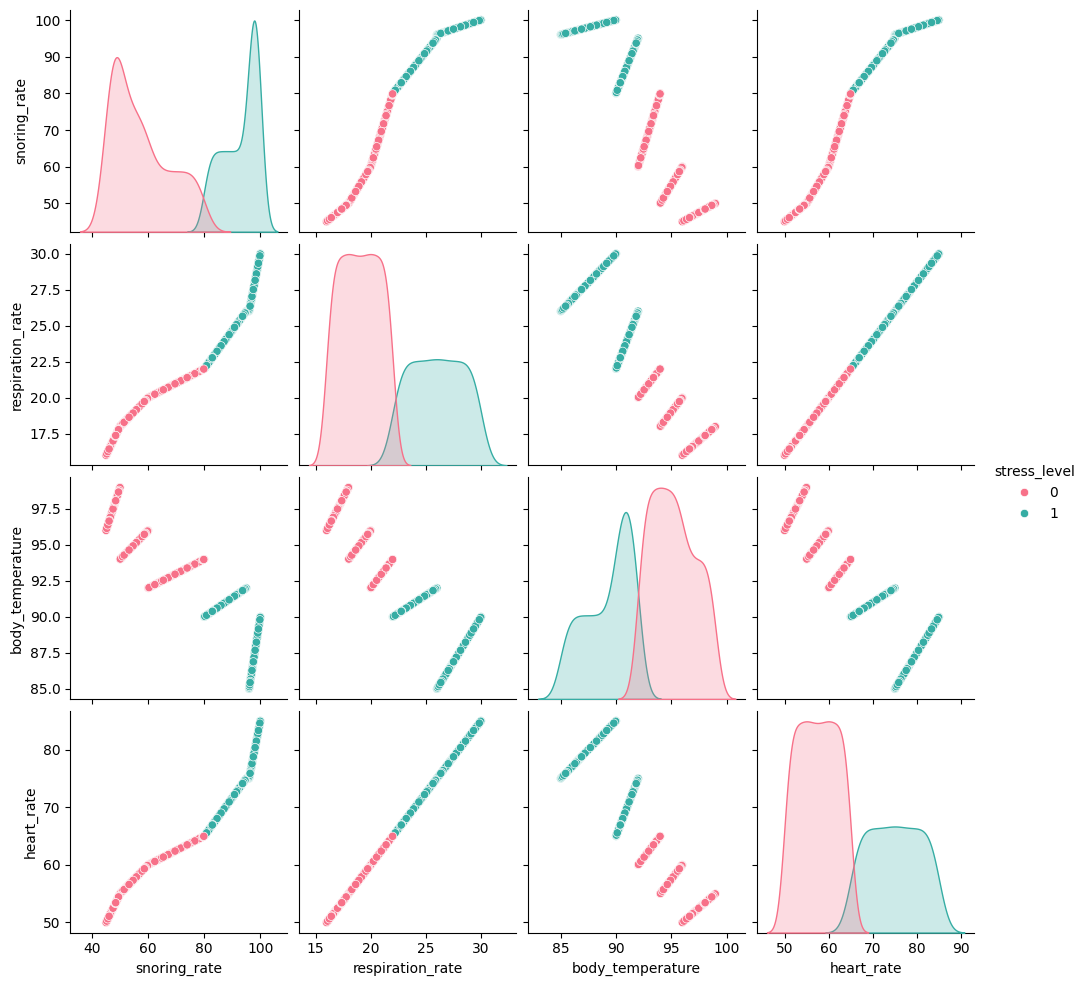

In [44]:
# Pair plot for selected features
selected_cols = ['snoring_rate', 'respiration_rate', 'body_temperature', 'heart_rate', 'stress_level']
sns.pairplot(df[selected_cols], hue='stress_level', palette='husl')
plt.show()

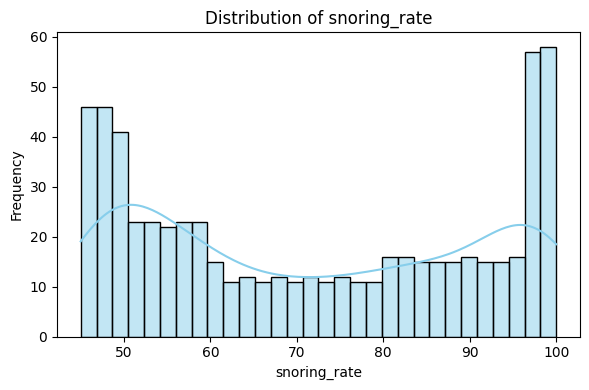

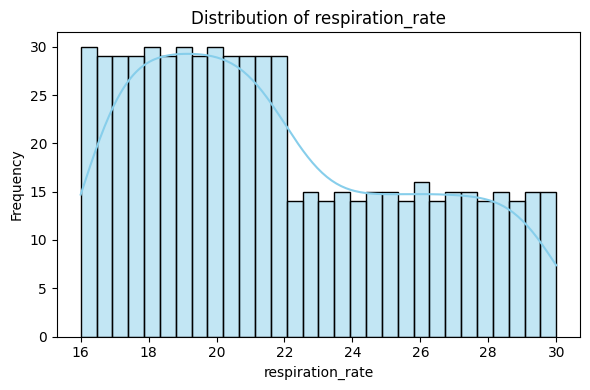

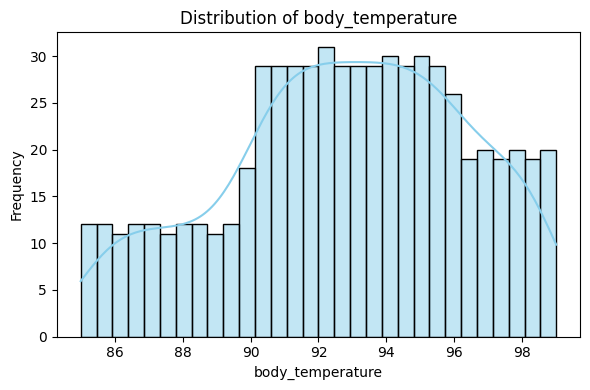

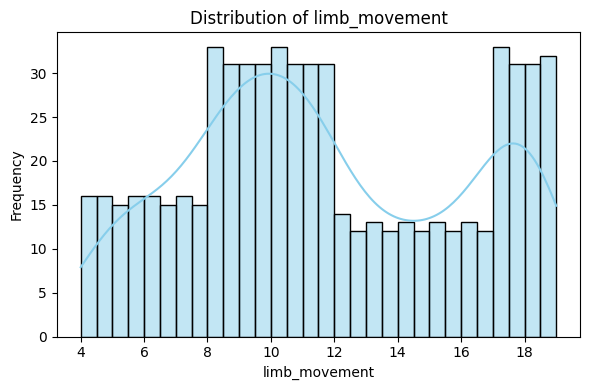

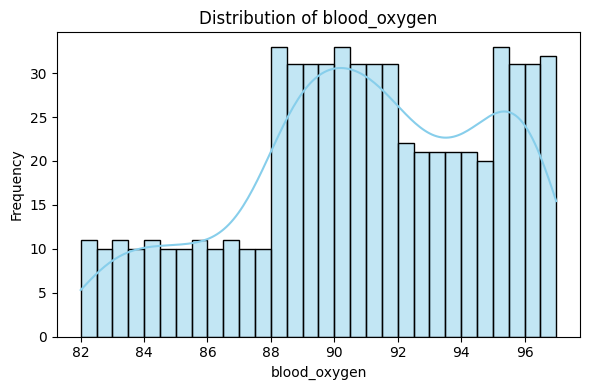

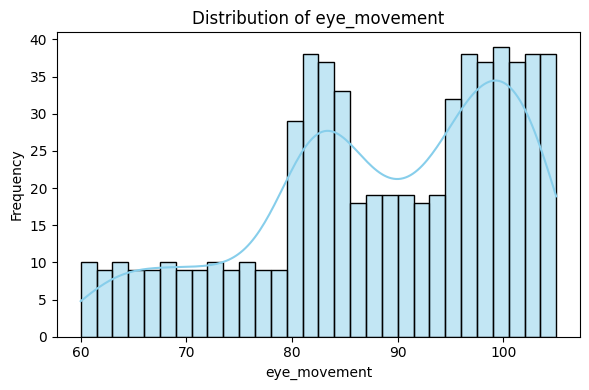

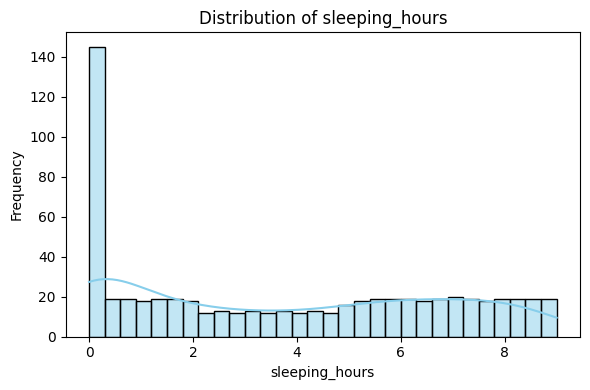

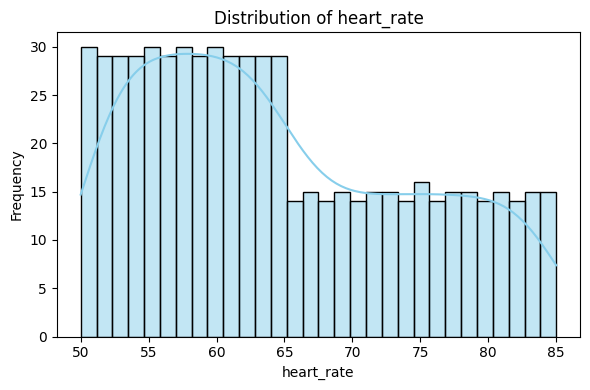

In [45]:
# Distribution plots
for col in df.columns[:-1]:  # excluding target
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

C:\Users\093\AppData\Local\Temp\ipykernel_10680\62943798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y=col, data=df, palette='Set2')


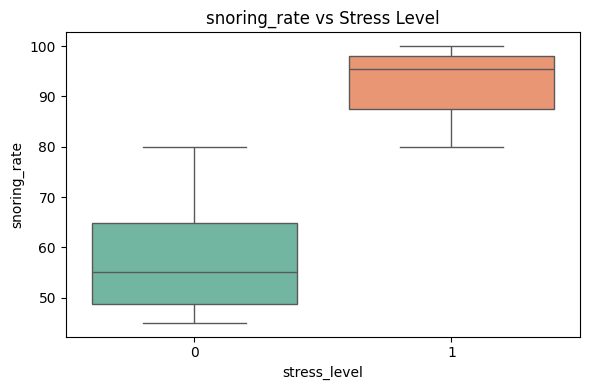

C:\Users\093\AppData\Local\Temp\ipykernel_10680\62943798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y=col, data=df, palette='Set2')


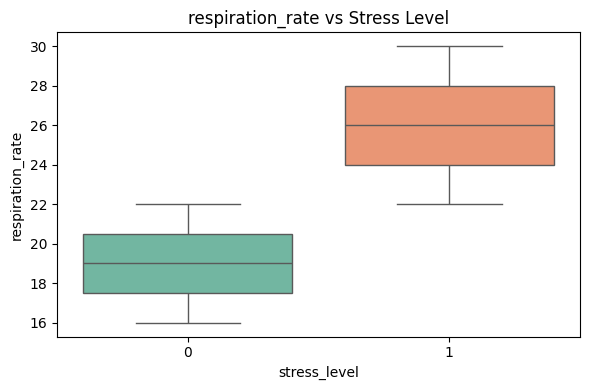

C:\Users\093\AppData\Local\Temp\ipykernel_10680\62943798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y=col, data=df, palette='Set2')


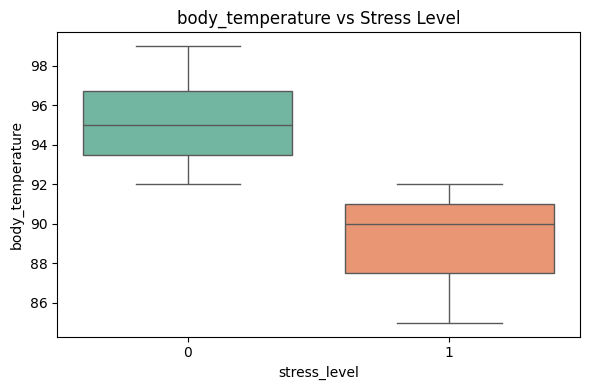

C:\Users\093\AppData\Local\Temp\ipykernel_10680\62943798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y=col, data=df, palette='Set2')


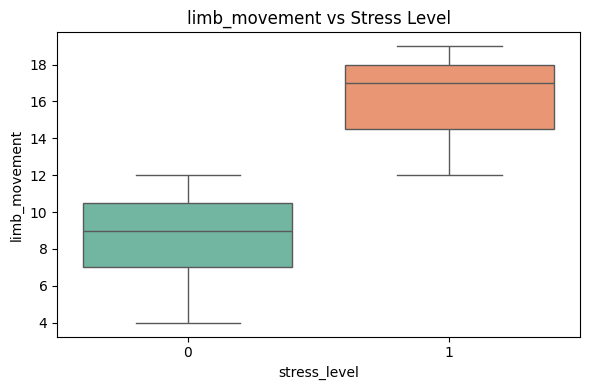

C:\Users\093\AppData\Local\Temp\ipykernel_10680\62943798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y=col, data=df, palette='Set2')


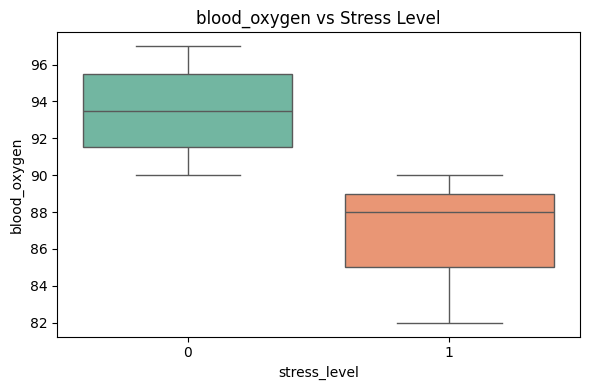

C:\Users\093\AppData\Local\Temp\ipykernel_10680\62943798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y=col, data=df, palette='Set2')


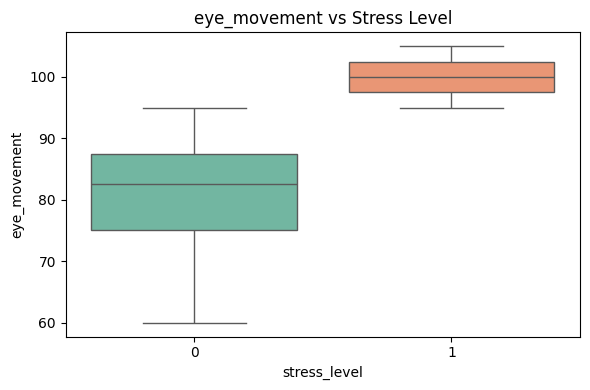

C:\Users\093\AppData\Local\Temp\ipykernel_10680\62943798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y=col, data=df, palette='Set2')


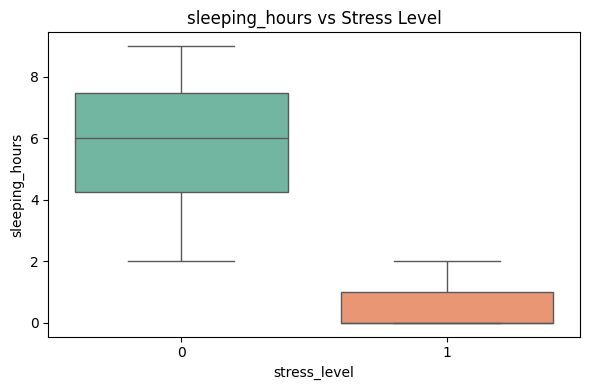

C:\Users\093\AppData\Local\Temp\ipykernel_10680\62943798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y=col, data=df, palette='Set2')


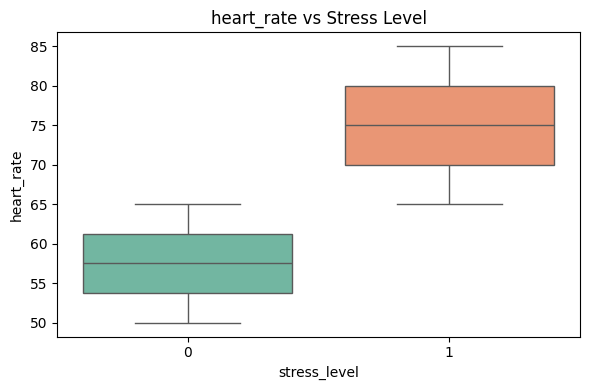

In [46]:
# Box plots to detect outliers
for col in df.columns[:-1]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='stress_level', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Stress Level')
    plt.tight_layout()
    plt.show()

In [47]:
# 5. Split features and labels
X = df.drop("stress_level", axis=1)  # or the correct label column
y = df["stress_level"]

In [48]:
# 6. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [49]:
# Balance data using SMOTE (handle class imbalance)
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)


 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        50

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126

Accuracy Score: 1.0


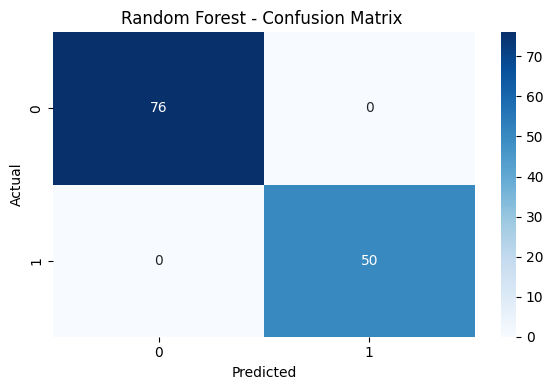

In [50]:
# Define model with regularization
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,               
    min_samples_leaf=10,       
    max_features='sqrt',       
    random_state=42
)

# Fit model on balanced data
rf_model.fit(X_train_bal, y_train_bal)

# Predict on original test set (unseen data)
y_pred = rf_model.predict(X_test)

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Accuracy Score:", accuracy_score(y_test, y_pred))

# 10. Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt='g')
plt.title("Random Forest - Confusion Matrix ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Saving Model

In [51]:
joblib.dump(rf_model, 'random_forest_stress_model.pkl')

['random_forest_stress_model.pkl']

## Logistic Regression


 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        50

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126

 Accuracy Score: 1.0


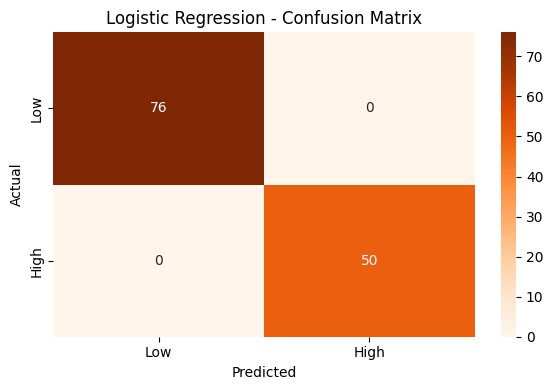

In [52]:
# Step 1: Create a weaker Logistic Regression model
lr_model = LogisticRegression(
    max_iter=100,          
    C=0.01,                
    class_weight=None,     
    solver='lbfgs',
    random_state=42
)

# Step 2: Train the model
lr_model.fit(X_train, y_train)

# Step 3: Predict
y_pred = lr_model.predict(X_test)

# Step 4: Evaluation
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))

print(" Accuracy Score:", accuracy_score(y_test, y_pred))

# Step 5: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Oranges", fmt='g', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [53]:
joblib.dump(lr_model, 'logistic_regression_stress_model.pkl')

['logistic_regression_stress_model.pkl']

## Decision Tree Classifier


 Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        76
           1       0.98      1.00      0.99        50

    accuracy                           0.99       126
   macro avg       0.99      0.99      0.99       126
weighted avg       0.99      0.99      0.99       126

 Accuracy Score: 0.9920634920634921


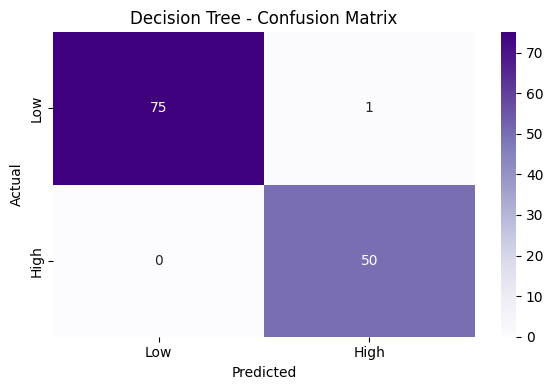

In [54]:
from sklearn.tree import DecisionTreeClassifier

#  Step 1: Add max_depth, min_samples_split, min_samples_leaf to reduce overfitting
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,            
    min_samples_split=10,    
    min_samples_leaf=5,       
    random_state=42
)

# Step 2: Train the model
dt_model.fit(X_train, y_train)

# Step 3: Predict
y_pred = dt_model.predict(X_test)

# Step 4: Evaluation
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))

print(" Accuracy Score:", accuracy_score(y_test, y_pred))

# Step 5: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Purples", fmt='g', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [55]:
joblib.dump(dt_model, 'decision_tree_model.pkl')

['decision_tree_model.pkl']

## MLP Classifier


 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        50

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126

 Accuracy Score: 1.0


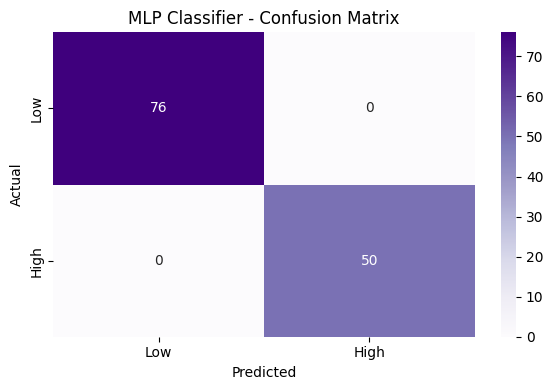

In [56]:
# 7. Build MLP Classifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  
    activation='relu',           
    solver='adam',               
    alpha=0.001,                
    max_iter=500,
    random_state=42
)

# 8. Train Model
mlp_model.fit(X_train, y_train)

# 9. Predict and Evaluate
y_pred = mlp_model.predict(X_test)

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))
print(" Accuracy Score:", accuracy_score(y_test, y_pred))

# 10. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Purples", fmt='g', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title("MLP Classifier - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [57]:
joblib.dump(mlp_model, 'mlp_classifier_model.pkl')

['mlp_classifier_model.pkl']